In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 设置中文显示（如果需要）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("库导入成功！")

库导入成功！


In [2]:
# 读取数据
df = pd.read_csv('company_data.csv')

# 查看数据
print("数据预览：")
print(df)

print("\n数据信息：")
df.info()

数据预览：
     年份   收入  利润
0  2020  100  15
1  2021  120  18
2  2022  140  22
3  2023  160  28
4  2024  185  35

数据信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   年份      5 non-null      int64
 1   收入      5 non-null      int64
 2   利润      5 non-null      int64
dtypes: int64(3)
memory usage: 252.0 bytes


In [3]:
# 计算增长率
df['收入增长率'] = df['收入'].pct_change() * 100
df['利润增长率'] = df['利润'].pct_change() * 100

# 计算利润率和累计利润
df['利润率'] = (df['利润'] / df['收入']) * 100
df['累计利润'] = df['利润'].cumsum()

print("=== 关键指标 ===\n")
print(f"总收入: {df['收入'].sum()} 万元")
print(f"总利润: {df['利润'].sum()} 万元")
print(f"平均利润率: {df['利润率'].mean():.2f}%")
print(f"利润最高年份: {df.loc[df['利润'].idxmax(), '年份']}年")

=== 关键指标 ===

总收入: 705 万元
总利润: 118 万元
平均利润率: 16.43%
利润最高年份: 2024年


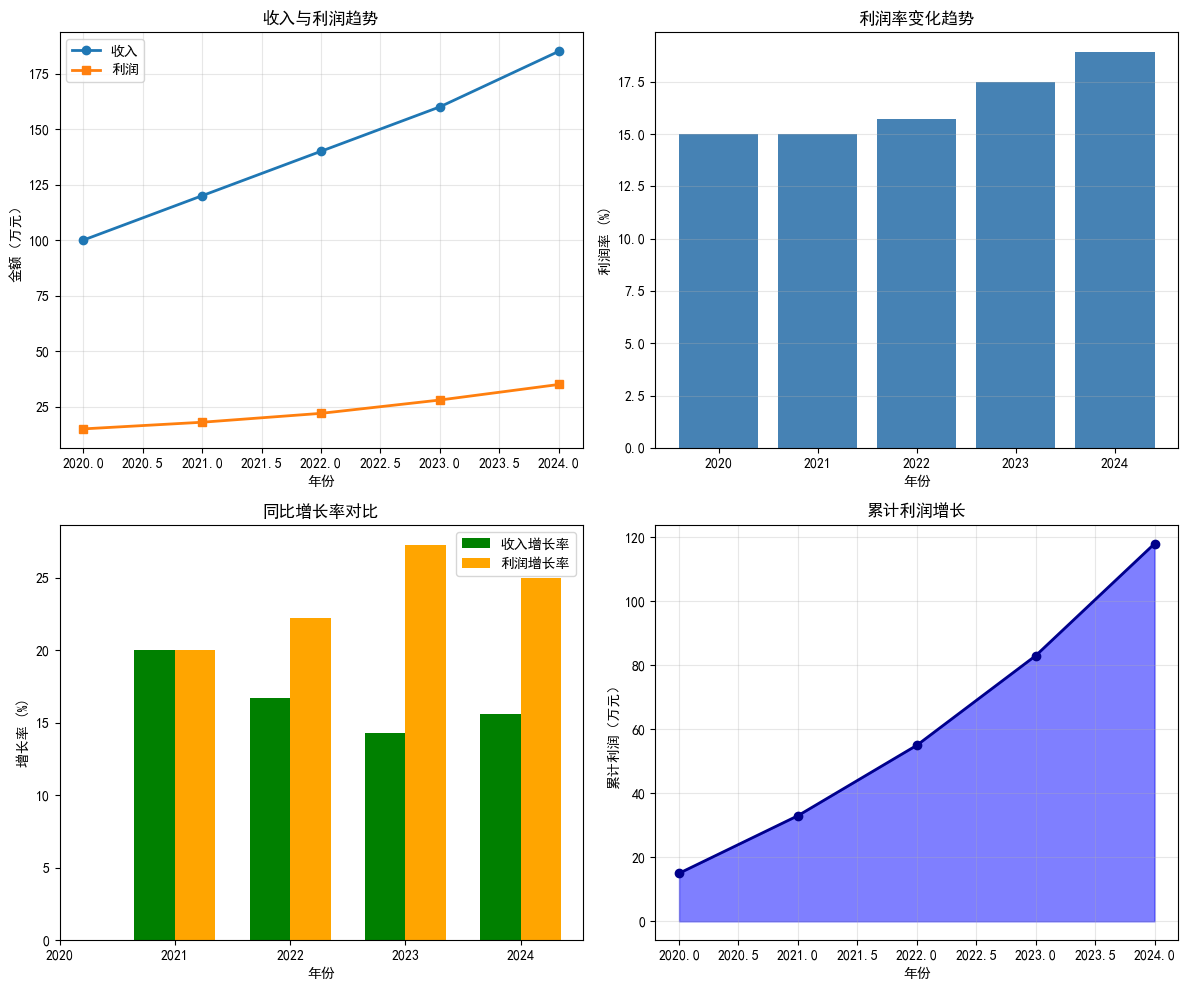

In [4]:
# 创建图表
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 图1：收入与利润趋势
axes[0, 0].plot(df['年份'], df['收入'], 'o-', linewidth=2, label='收入')
axes[0, 0].plot(df['年份'], df['利润'], 's-', linewidth=2, label='利润')
axes[0, 0].set_xlabel('年份')
axes[0, 0].set_ylabel('金额（万元）')
axes[0, 0].set_title('收入与利润趋势')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 图2：利润率变化
axes[0, 1].bar(df['年份'], df['利润率'], color='steelblue')
axes[0, 1].set_xlabel('年份')
axes[0, 1].set_ylabel('利润率 (%)')
axes[0, 1].set_title('利润率变化趋势')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 图3：增长率对比
x = np.arange(len(df))
width = 0.35
axes[1, 0].bar(x - width/2, df['收入增长率'], width, label='收入增长率', color='green')
axes[1, 0].bar(x + width/2, df['利润增长率'], width, label='利润增长率', color='orange')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(df['年份'])
axes[1, 0].set_xlabel('年份')
axes[1, 0].set_ylabel('增长率 (%)')
axes[1, 0].set_title('同比增长率对比')
axes[1, 0].legend()
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# 图4：累计利润
axes[1, 1].fill_between(df['年份'], df['累计利润'], alpha=0.5, color='blue')
axes[1, 1].plot(df['年份'], df['累计利润'], 'o-', color='darkblue', linewidth=2)
axes[1, 1].set_xlabel('年份')
axes[1, 1].set_ylabel('累计利润（万元）')
axes[1, 1].set_title('累计利润增长')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
print("=" * 50)
print("📊 分析结论")
print("=" * 50)

print("1. 收入从2020年的100万元增长到2024年的185万元，增长85%")
print("2. 利润从15万元增长到35万元，增长133%")
print("3. 利润率从15%提升到约18.9%，盈利能力改善")
print("4. 利润增速超过收入增速，显示成本控制有效")
print("5. 累计利润达到118万元，企业整体盈利稳健")

📊 分析结论
1. 收入从2020年的100万元增长到2024年的185万元，增长85%
2. 利润从15万元增长到35万元，增长133%
3. 利润率从15%提升到约18.9%，盈利能力改善
4. 利润增速超过收入增速，显示成本控制有效
5. 累计利润达到118万元，企业整体盈利稳健
